In [ ]:
MVP Step

Profile 입력

Play Agent

Interaction Agent

Epigenetic Agent

Nudge Agent

Explanation Agent

이렇게만 해도
BebePlay/BabyCoach의 차별성이 바로 보입니다.

영양(Spoon)은 2차로 붙여도 됩니다.

## 전체 Process
- Step 1. 문제 정의와 입력 정의
- Step 2. 상태(State) 설계
- Step 3. 개별 Agent 로직 개발
- Step 4. LangGraph 노드 분리
- Step 5. Orchestrator 흐름 연결
- Step 6. 출력 구조 정리
- Step 6-1. GPT-5 mini 기반 설명 생성 연결
- Step 6-2. 샘플 입력으로 end-to-end 실행 확인

In [1]:
# ============================================================
# [Step 0] 필수 라이브러리 import
# ------------------------------------------------------------
# 이 셀은 BabyCoach LangGraph MVP에 필요한 기본 라이브러리를 불러옵니다.
# - TypedDict: LangGraph 상태(State) 타입 정의
# - dataclass: 설정값/구조체 정의 시 사용 가능
# - pprint: 결과를 보기 좋게 출력
# - math/statistics: 간단한 점수 계산 보조
# ============================================================

from typing import TypedDict, Dict, List, Any, Optional
from dataclasses import dataclass
from pprint import pprint
import math
import statistics
from langgraph.graph import StateGraph, END

import os
from dotenv import load_dotenv
from openai import OpenAI

# .env 로드
load_dotenv(r"D:\PyProject\env_keys\.env")

# 키 확인
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is None:
    raise ValueError("OPENAI_API_KEY가 로드되지 않았습니다. .env 확인하세요.")

# 환경변수 등록 (선택)
os.environ["OPENAI_API_KEY"] = openai_key

# client 생성
client = OpenAI(api_key=openai_key)

MODEL_NAME = "gpt-5-mini"

print("OpenAI 연결 준비 완료")

OpenAI 연결 준비 완료


### Step 1. 문제 정의와 입력 정의
- 아기 프로필: 월령, 알레르기, 몸무게
- 영양/식사 기록, 먹은 식재료, 양, 거부 여부
- 놀이 기록: 놀이 종류, 집중 시간, 반응
- 부모 상호작용 기록: 따라 말하기, 스킨십, 반응성
- 부모 질문
- 선택적 사진
#### 출력 예시
- 오늘의 식사 제안
- 오늘의 놀이 제안
- 오늘의 관찰 포인트
- 짧은 넛지 문구
- 설명 문장
#### Step의 산출물
- input_schema.md
- output_schema.md
- MVP 기능 목록

In [4]:
# ============================================================
# [Step 1] 입력 스키마 예시 데이터 정의
# ------------------------------------------------------------
# 이 셀은 BabyCoach가 입력으로 받는 기본 데이터 예시를 정의합니다.
# 실제 서비스에서는 DB/폼/API에서 들어오겠지만,
# 지금은 노트북 MVP이므로 하나의 샘플 딕셔너리로 구성합니다.
# ============================================================

sample_input = {
    "child_profile": {
        "child_id": "baby_001",
        "name": "아기A",
        "age_months": 10,
        "weight_kg": 8.7,
        "allergies": ["egg_white"],
        "notes": "새로운 음식은 조심스럽게 도입 중"
    },
    "meal_log": {
        "recent_foods": ["rice", "carrot", "tofu", "banana", "rice"],
        "protein_count_3d": 1,
        "vegetable_count_3d": 2,
        "food_diversity_3d": 4,
        "meal_refusal": False,
        "reaction_flags": []
    },
    "play_log": {
        "play_types": ["촉감놀이", "딸랑이 흔들기", "넣기/빼기"],
        "focus_minutes": 7,
        "repeat_count": 4,
        "refusal": False,
        "child_led_ratio": 0.65,
        "parent_note": "손으로 만지고 흔드는 놀이를 좋아함"
    },
    "interaction_log": {
        "touch_count": 4,
        "labeling_count": 3,
        "joint_attention_count": 2,
        "responsive_turns": 5,
        "flat_response": False,
        "parent_note": "아이가 쳐다보면 같이 반응해 주려고 노력함"
    },
    "parent_query": "오늘은 어떤 놀이와 관찰 포인트가 좋을까요?"
}

pprint(sample_input)

{'child_profile': {'age_months': 10,
                   'allergies': ['egg_white'],
                   'child_id': 'baby_001',
                   'name': '아기A',
                   'notes': '새로운 음식은 조심스럽게 도입 중',
                   'weight_kg': 8.7},
 'interaction_log': {'flat_response': False,
                     'joint_attention_count': 2,
                     'labeling_count': 3,
                     'parent_note': '아이가 쳐다보면 같이 반응해 주려고 노력함',
                     'responsive_turns': 5,
                     'touch_count': 4},
 'meal_log': {'food_diversity_3d': 4,
              'meal_refusal': False,
              'protein_count_3d': 1,
              'reaction_flags': [],
              'recent_foods': ['rice', 'carrot', 'tofu', 'banana', 'rice'],
              'vegetable_count_3d': 2},
 'parent_query': '오늘은 어떤 놀이와 관찰 포인트가 좋을까요?',
 'play_log': {'child_led_ratio': 0.65,
              'focus_minutes': 7,
              'parent_note': '손으로 만지고 흔드는 놀이를 좋아함',
              'play_types': ['촉감놀이

### Step 2. State 설계
- 목표: LangGraph에서 흘러다닐 공통 상태 객체를 정의
- LangGraph는 결국 상태 기반입니다. 그래서 “각 노드가 무엇을 읽고 무엇을 업데이트하는지”를 정해야 합니다.
#### 개발할 것 
- BabyCoachState 정의
- 필드 구조 설계
- 각 노드의 입출력 필드 지정
#### Step의 산출물
- state_schema.py
- 상태 흐름도

In [7]:
# ============================================================
# [Step 2] LangGraph 공통 상태(State) 정의
# ------------------------------------------------------------
# 이 셀은 LangGraph에서 각 노드가 공유할 상태 구조를 정의합니다.
# 입력 데이터와 중간 결과, 최종 결과를 모두 하나의 State 안에서 관리합니다.
# ============================================================

class BabyCoachState(TypedDict, total=False):
    # 입력
    child_profile: Dict[str, Any]
    meal_log: Dict[str, Any]
    play_log: Dict[str, Any]
    interaction_log: Dict[str, Any]
    parent_query: str

    # 중간 결과
    nutrition_result: Dict[str, Any]
    play_result: Dict[str, Any]
    interaction_result: Dict[str, Any]
    epigenetic_result: Dict[str, Any]
    growth_result: Dict[str, Any]
    ranked_actions: List[Dict[str, Any]]

    # 최종 결과
    nudge_message: str
    explanation: str
    final_output: Dict[str, Any]

### Step 3. 개별 Agent 로직 개발
- 이 단계는 LangGraph보다 먼저 해야 합니다. 왜냐하면 노드 안에서 실제로 돌 로직이 있어야 하기 때문입니다.

- Step 3-1. Nutrition Agent 개발
- Step 3-2. Play Agent 개발
- Step 3-3. Interaction Agent 개발
- Step 3-4. Epigenetic Interpreter 개발
- Step 3-5. Growth Agent 개발
- Step 3-6. Recommendation Ranker 개발
- Step 3-7. Nudge Agent 개발
- Step 3-8. Explanation Agent 개발

In [10]:
# ============================================================
# [Step 3-1] Nutrition Agent 개발
# ------------------------------------------------------------
# 이 셀은 영양 섭취 환경을 해석하는 Nutrition Agent입니다.
# 초기 MVP이므로 룰 기반으로 구현합니다.
#
# 해석 목표:
# - 단백질 섭취 균형
# - 채소 섭취 수준
# - 식재료 다양성
# - 반복 식단 여부
# - 식사 거부/반응 위험 플래그
# ============================================================

def nutrition_agent(state: BabyCoachState) -> BabyCoachState:
    meal = state["meal_log"]
    profile = state["child_profile"]

    protein_count = meal.get("protein_count_3d", 0)
    vegetable_count = meal.get("vegetable_count_3d", 0)
    diversity = meal.get("food_diversity_3d", 0)
    refusal = meal.get("meal_refusal", False)
    reactions = meal.get("reaction_flags", [])

    # 간단 점수화
    protein_balance = min(protein_count / 3.0, 1.0)
    vegetable_balance = min(vegetable_count / 3.0, 1.0)
    diversity_score = min(diversity / 6.0, 1.0)

    repeated_pattern = diversity <= 3
    risk_flag = refusal or (len(reactions) > 0)

    # 해석
    if diversity_score < 0.5:
        nutrition_pattern = "low_diversity"
    elif protein_balance < 0.5:
        nutrition_pattern = "low_protein"
    else:
        nutrition_pattern = "balanced"

    nutrition_result = {
        "protein_balance": round(protein_balance, 2),
        "vegetable_balance": round(vegetable_balance, 2),
        "diversity_score": round(diversity_score, 2),
        "repeated_pattern": repeated_pattern,
        "risk_flag": risk_flag,
        "nutrition_pattern": nutrition_pattern,
        "allergy_context": profile.get("allergies", [])
    }

    state["nutrition_result"] = nutrition_result
    return state

In [12]:
# ============================================================
# [Step 3-2] Play Agent 개발
# ------------------------------------------------------------
# 이 셀은 놀이 상태를 해석하는 Play Agent입니다.
# Bird & Edwards의 탐색(exploration) / 문제해결(problem solving) 관점을
# 아주 단순한 규칙 기반 점수로 먼저 구현합니다.
#
# 해석 목표:
# - exploration score
# - problem solving score
# - engagement score
# - avoidance 여부
# ============================================================

def play_agent(state: BabyCoachState) -> BabyCoachState:
    play = state["play_log"]
    age_months = state["child_profile"]["age_months"]

    play_types = play.get("play_types", [])
    focus_minutes = play.get("focus_minutes", 0)
    repeat_count = play.get("repeat_count", 0)
    refusal = play.get("refusal", False)
    child_led_ratio = play.get("child_led_ratio", 0.0)
    note = play.get("parent_note", "")

    exploration_keywords = ["촉감", "흔들기", "딸랑이", "만지기", "소리", "쥐고", "놓기"]
    problem_solving_keywords = ["넣기/빼기", "쌓기", "버튼", "원인", "결과", "맞추기"]

    exploration_hits = 0
    problem_hits = 0

    for p in play_types:
        if any(k in p for k in exploration_keywords):
            exploration_hits += 1
        if any(k in p for k in problem_solving_keywords):
            problem_hits += 1

    exploration_score = min((exploration_hits * 0.3) + (child_led_ratio * 0.4) + min(focus_minutes / 10, 0.3), 1.0)
    problem_solving_score = min((problem_hits * 0.35) + min(repeat_count / 10, 0.3) + min(focus_minutes / 15, 0.2), 1.0)
    engagement_score = min((min(focus_minutes / 10, 0.5) + child_led_ratio * 0.5), 1.0)

    play_stage = "exploration"
    if problem_solving_score > exploration_score:
        play_stage = "problem_solving"

    play_result = {
        "exploration_score": round(exploration_score, 2),
        "problem_solving_score": round(problem_solving_score, 2),
        "engagement_score": round(engagement_score, 2),
        "avoidance_flag": refusal,
        "play_stage": play_stage,
        "play_note_summary": note
    }

    state["play_result"] = play_result
    return state

In [14]:
# ============================================================
# [Step 3-3] Interaction Agent 개발
# ------------------------------------------------------------
# 이 셀은 부모-아기 상호작용의 질을 정량화하는 Interaction Agent입니다.
# 여기서 상호작용은 단순한 "같이 있음"이 아니라,
# 아이의 경험이 어떻게 제공되는지를 결정하는 핵심 환경 변수로 봅니다.
#
# 해석 목표:
# - 반응성(responsiveness)
# - 공동주의(joint attention)
# - 터치/스킨십 수준
# - 상호작용 품질
# ============================================================

def interaction_agent(state: BabyCoachState) -> BabyCoachState:
    inter = state["interaction_log"]

    touch_count = inter.get("touch_count", 0)
    labeling_count = inter.get("labeling_count", 0)
    joint_attention_count = inter.get("joint_attention_count", 0)
    responsive_turns = inter.get("responsive_turns", 0)
    flat_response = inter.get("flat_response", False)

    responsiveness_score = min((responsive_turns / 6.0), 1.0)
    joint_attention_score = min((joint_attention_count / 4.0), 1.0)
    touch_score = min((touch_count / 5.0), 1.0)
    labeling_score = min((labeling_count / 4.0), 1.0)

    total_score = (responsiveness_score * 0.4 +
                   joint_attention_score * 0.2 +
                   touch_score * 0.2 +
                   labeling_score * 0.2)

    if flat_response:
        interaction_quality = "needs_support"
    elif total_score >= 0.7:
        interaction_quality = "stable"
    elif total_score >= 0.45:
        interaction_quality = "moderate"
    else:
        interaction_quality = "needs_support"

    interaction_result = {
        "responsiveness_score": round(responsiveness_score, 2),
        "joint_attention_score": round(joint_attention_score, 2),
        "touch_score": round(touch_score, 2),
        "labeling_score": round(labeling_score, 2),
        "interaction_quality": interaction_quality,
        "flat_response": flat_response
    }

    state["interaction_result"] = interaction_result
    return state

In [16]:
# ============================================================
# [Step 3-4] Epigenetic Interpreter Agent 개발
# ------------------------------------------------------------
# 이 셀은 Nutrition / Play / Interaction 결과를 통합하여,
# "환경이 발달에 어떤 방향의 영향을 줄 수 있는가"를 해석하는 핵심 Agent입니다.
#
# 주의:
# - 의학적 진단을 하지 않습니다.
# - "가능성", "환경 신호", "관찰 포인트" 수준으로 해석합니다.
# ============================================================

def epigenetic_agent(state: BabyCoachState) -> BabyCoachState:
    nutrition = state["nutrition_result"]
    play = state["play_result"]
    interaction = state["interaction_result"]

    # 스트레스 조절 환경
    if interaction["interaction_quality"] == "stable" and interaction["touch_score"] >= 0.6:
        stress_regulation = "supportive"
    elif interaction["interaction_quality"] == "needs_support":
        stress_regulation = "watch"
    else:
        stress_regulation = "moderate"

    # 인지 자극 환경
    cognitive_stimulation_score = (
        play["exploration_score"] * 0.45 +
        play["problem_solving_score"] * 0.35 +
        nutrition["diversity_score"] * 0.20
    )

    if cognitive_stimulation_score >= 0.7:
        cognitive_stimulation = "rich"
    elif cognitive_stimulation_score >= 0.45:
        cognitive_stimulation = "moderate"
    else:
        cognitive_stimulation = "limited"

    # 사회정서적 결속
    if interaction["joint_attention_score"] >= 0.5 and interaction["responsiveness_score"] >= 0.65:
        social_bonding = "high"
    elif interaction["responsiveness_score"] >= 0.4:
        social_bonding = "moderate"
    else:
        social_bonding = "low"

    # 위험/관찰 신호
    risk_signals = []
    if nutrition["nutrition_pattern"] == "low_diversity":
        risk_signals.append("영양 경험 다양성 부족 가능성")
    if play["engagement_score"] < 0.4:
        risk_signals.append("놀이 몰입도 낮음")
    if interaction["interaction_quality"] == "needs_support":
        risk_signals.append("상호작용 안정성 보완 필요")

    epigenetic_result = {
        "stress_regulation": stress_regulation,
        "cognitive_stimulation": cognitive_stimulation,
        "social_bonding": social_bonding,
        "risk_signals": risk_signals,
        "cognitive_stimulation_score": round(cognitive_stimulation_score, 2)
    }

    state["epigenetic_result"] = epigenetic_result
    return state

In [18]:
# ============================================================
# [Step 3-5] Growth Agent 개발
# ------------------------------------------------------------
# 이 셀은 발달을 "진단"하는 것이 아니라,
# 부모가 오늘/이번 주에 무엇을 관찰하면 좋은지를 정리하는 Agent입니다.
#
# 출력:
# - 유지할 점
# - 강화할 점
# - 관찰 포인트
# ============================================================

def growth_agent(state: BabyCoachState) -> BabyCoachState:
    epi = state["epigenetic_result"]
    play = state["play_result"]
    nutrition = state["nutrition_result"]
    interaction = state["interaction_result"]

    keep_points = []
    improve_points = []
    observe_points = []

    if epi["social_bonding"] == "high":
        keep_points.append("현재의 반응적인 상호작용을 유지해 주세요")
    if epi["stress_regulation"] == "supportive":
        keep_points.append("정서적으로 안정적인 환경 신호가 보입니다")

    if nutrition["diversity_score"] < 0.5:
        improve_points.append("식재료 경험의 다양성을 조금씩 넓혀볼 필요가 있습니다")
    if play["play_stage"] == "exploration":
        improve_points.append("탐색 놀이를 유지하면서 간단한 문제해결 놀이를 조금 추가해보세요")
    if interaction["interaction_quality"] != "stable":
        improve_points.append("아이의 시선과 행동에 맞춰 반응하는 빈도를 늘려보세요")

    if play["exploration_score"] >= 0.6:
        observe_points.append("아이가 감각 자극을 어떻게 탐색하는지 관찰해 보세요")
    if play["problem_solving_score"] < 0.4:
        observe_points.append("넣기/빼기, 누르면 반응하는 놀이에서 시도 변화가 나타나는지 살펴보세요")
    if nutrition["repeated_pattern"]:
        observe_points.append("같은 식재료 반복 시 반응 차이가 있는지 기록해 보세요")

    growth_result = {
        "keep_points": keep_points[:2],
        "improve_points": improve_points[:3],
        "observe_points": observe_points[:3]
    }

    state["growth_result"] = growth_result
    return state

In [20]:
# ============================================================
# [Step 3-6] Recommendation Ranker Agent 개발
# ------------------------------------------------------------
# 이 셀은 Nutrition / Play / Interaction / Epigenetic 결과를 기반으로
# 오늘의 행동 추천 후보를 만들고 점수화하여 우선순위를 정합니다.
#
# MVP에서는 룰 기반으로 추천 후보를 만들고 단순 점수 정렬을 합니다.
# ============================================================

def ranker_agent(state: BabyCoachState) -> BabyCoachState:
    nutrition = state["nutrition_result"]
    play = state["play_result"]
    interaction = state["interaction_result"]
    epi = state["epigenetic_result"]

    candidates = []

    # 영양 관련 추천
    if nutrition["nutrition_pattern"] == "low_protein":
        candidates.append({
            "domain": "spoon",
            "action": "단백질 식재료를 포함한 식단을 소량으로 제안하기",
            "score": 0.82
        })

    if nutrition["nutrition_pattern"] == "low_diversity":
        candidates.append({
            "domain": "spoon",
            "action": "새로운 식재료를 아주 소량으로 추가해 보기",
            "score": 0.78
        })

    # 놀이 관련 추천
    if play["play_stage"] == "exploration":
        candidates.append({
            "domain": "play",
            "action": "촉감과 소리 반응 중심의 탐색 놀이 진행하기",
            "score": 0.84
        })
        candidates.append({
            "domain": "play",
            "action": "넣기/빼기 같은 간단한 문제해결 놀이 추가하기",
            "score": 0.73
        })
    else:
        candidates.append({
            "domain": "play",
            "action": "원인-결과가 있는 반복 놀이를 확장하기",
            "score": 0.81
        })

    # 상호작용 관련 추천
    if interaction["interaction_quality"] != "stable":
        candidates.append({
            "domain": "interaction",
            "action": "아이의 시선과 행동에 바로 반응하는 상호작용 늘리기",
            "score": 0.86
        })

    if interaction["touch_score"] < 0.6:
        candidates.append({
            "domain": "interaction",
            "action": "짧은 스킨십과 함께 말 걸기 늘리기",
            "score": 0.75
        })

    # 인지 자극 제한 시
    if epi["cognitive_stimulation"] == "limited":
        candidates.append({
            "domain": "growth",
            "action": "짧고 다양한 감각 자극 경험을 하루에 1~2회 추가하기",
            "score": 0.88
        })

    ranked_actions = sorted(candidates, key=lambda x: x["score"], reverse=True)
    state["ranked_actions"] = ranked_actions[:5]
    return state

In [22]:
# ============================================================
#  GPT-5 mini용 프롬프트 빌더 개발
# ------------------------------------------------------------
# 이 셀은 Nudge Agent와 Explanation Agent에서 공통으로 사용할
# GPT-5 mini 입력 프롬프트를 만드는 보조 함수입니다.
#
# 목적:
# - Nutrition / Play / Interaction / Epigenetic / Growth 결과를
#   하나의 자연어 문맥으로 묶어 GPT에게 전달
# - 의료적 진단이 아닌 "환경 해석 + 행동 제안" 구조 유지
# ============================================================

def build_llm_context(state: BabyCoachState) -> str:
    child = state["child_profile"]
    nutrition = state["nutrition_result"]
    play = state["play_result"]
    interaction = state["interaction_result"]
    epi = state["epigenetic_result"]
    growth = state["growth_result"]
    ranked = state.get("ranked_actions", [])

    ranked_text = "\n".join(
        [f"- [{x['domain']}] {x['action']} (score={x['score']})" for x in ranked]
    ) if ranked else "- 추천 후보 없음"

    prompt = f"""
[아이 프로필]
- child_id: {child.get('child_id')}
- 이름: {child.get('name')}
- 월령: {child.get('age_months')}개월
- 체중: {child.get('weight_kg')}kg
- 알레르기: {child.get('allergies', [])}
- 참고 메모: {child.get('notes', '')}

[부모 질문]
{state.get('parent_query', '')}

[영양 환경 해석]
{nutrition}

[놀이 환경 해석]
{play}

[상호작용 환경 해석]
{interaction}

[후성유전학적 환경 해석]
{epi}

[관찰 포인트]
{growth}

[추천 후보]
{ranked_text}
"""
    return prompt.strip()

In [24]:
# ============================================================
# [Step 3-7] GPT-5 mini 기반 Nudge Agent 개발
# ------------------------------------------------------------
# 이 셀은 ranker 결과를 바탕으로 GPT-5 mini가 부모에게 보여줄
# 짧고 실행 가능한 넛지 문구를 생성합니다.
#
# 원칙:
# - 짧고 부담 없게
# - 강요하지 않기
# - 1개 행동만 제안
# - 의학적 진단 금지
# ============================================================

def nudge_agent(state: BabyCoachState) -> BabyCoachState:
    ranked = state.get("ranked_actions", [])
    llm_context = build_llm_context(state)

    if not ranked:
        state["nudge_message"] = "오늘은 아이의 반응을 5분만 천천히 관찰해 보세요."
        return state

    system_prompt = """
당신은 영유아 부모를 돕는 육아 코치입니다.

규칙:
1. 부모가 오늘 바로 실천할 수 있는 짧은 넛지 1문장만 작성하세요.
2. 40자~80자 정도의 자연스러운 한국어 문장으로 작성하세요.
3. 강요하지 말고 부드럽게 제안하세요.
4. 의학적 진단이나 공포 유발 표현은 금지합니다.
5. "오늘은", "짧게", "가볍게" 같은 실행 친화적 톤을 선호합니다.
"""

    user_prompt = f"""
다음 BabyCoach 해석 결과를 바탕으로,
부모가 오늘 바로 실천할 수 있는 넛지 문구 1개만 작성하세요.

{llm_context}
"""

    try:
        response = client.responses.create(
            model=MODEL_NAME,
            instructions=system_prompt,
            input=user_prompt,
        )
        nudge = response.output_text.strip()

        if not nudge:
            raise ValueError("빈 응답")

    except Exception:
        # fallback
        top_action = ranked[0]["action"]
        if "탐색 놀이" in top_action:
            nudge = "오늘은 5분만 촉감이나 소리 중심의 자유 탐색 놀이를 해보세요."
        elif "문제해결" in top_action:
            nudge = "오늘은 넣기/빼기처럼 결과가 보이는 놀이를 짧게 시도해 보세요."
        elif "스킨십" in top_action:
            nudge = "오늘은 스킨십과 함께 짧게 말을 걸어주는 시간을 조금 늘려보세요."
        elif "식재료" in top_action:
            nudge = "오늘은 익숙한 식단에 새로운 식재료를 아주 소량만 더해 보세요."
        else:
            nudge = f"오늘은 '{top_action}'를 짧고 가볍게 시도해 보세요."

    state["nudge_message"] = nudge
    return state

In [26]:
# ============================================================
# [Step 3-8] GPT-5 mini 기반 Explanation Agent 개발
# ------------------------------------------------------------
# 이 셀은 Nutrition / Play / Interaction / Epigenetic / Growth 결과를
# 부모가 이해하기 쉬운 자연어 설명으로 바꿉니다.
#
# 원칙:
# - 진단이 아니라 환경 해석
# - 후성유전학적 관점은 "환경 신호" 수준에서 설명
# - 부모 불안 유발 금지
# - 마지막 문장에는 nudge_message를 자연스럽게 연결
# ============================================================

def explanation_agent(state: BabyCoachState) -> BabyCoachState:
    llm_context = build_llm_context(state)
    nudge = state.get("nudge_message", "")

    system_prompt = """
당신은 후성유전학 기반 육아 코칭 AI입니다.

반드시 지킬 규칙:
1. 의학적 진단을 하지 마세요.
2. "환경", "경향", "경험", "상호작용", "관찰 포인트" 중심으로 설명하세요.
3. 부모가 불안해하지 않도록 부드럽고 신뢰감 있게 작성하세요.
4. 4~6문장 정도의 짧은 한국어 설명으로 작성하세요.
5. 후성유전학적 해석은 과장하지 말고,
   "환경이 발달 경험에 영향을 줄 수 있다" 수준에서만 말하세요.
6. 마지막 문장에는 오늘의 실천 제안을 자연스럽게 연결하세요.
"""

    user_prompt = f"""
다음 BabyCoach 해석 결과를 바탕으로 부모 설명문을 작성하세요.

설명 구조:
- 현재 상태 한 줄 요약
- 놀이/상호작용/영양 환경 해석
- 발달 경험 측면에서 왜 의미가 있는지
- 오늘 실천 제안 연결

오늘의 실천 제안:
{nudge}

해석 결과:
{llm_context}
"""

    try:
        response = client.responses.create(
            model=MODEL_NAME,
            instructions=system_prompt,
            input=user_prompt,
        )
        explanation = response.output_text.strip()

        if not explanation:
            raise ValueError("빈 응답")

    except Exception:
        # fallback
        nutrition = state["nutrition_result"]
        play = state["play_result"]
        interaction = state["interaction_result"]
        epi = state["epigenetic_result"]

        explanation_parts = []

        if nutrition["nutrition_pattern"] == "low_diversity":
            explanation_parts.append("최근 식재료 경험의 다양성이 다소 제한되어 있어 새로운 영양 경험을 천천히 넓혀볼 필요가 있습니다.")
        elif nutrition["nutrition_pattern"] == "low_protein":
            explanation_parts.append("최근 단백질 섭취 균형이 다소 낮아 식단 구성 보완이 도움이 될 수 있습니다.")
        else:
            explanation_parts.append("최근 영양 섭취 환경은 비교적 안정적인 흐름을 보이고 있습니다.")

        if play["play_stage"] == "exploration":
            explanation_parts.append("현재는 감각을 탐색하며 경험을 넓혀가는 단계의 놀이 특성이 잘 나타납니다.")
        else:
            explanation_parts.append("현재는 간단한 문제해결 경험으로 확장해볼 수 있는 놀이 신호가 보입니다.")

        if interaction["interaction_quality"] == "stable":
            explanation_parts.append("부모의 반응적인 상호작용은 정서적 안정과 사회적 결속 형성에 긍정적인 환경 신호가 될 수 있습니다.")
        else:
            explanation_parts.append("아이의 시선과 행동에 맞춰 반응하는 빈도를 조금 더 늘리면 상호작용의 질을 높이는 데 도움이 될 수 있습니다.")

        if epi["cognitive_stimulation"] == "rich":
            explanation_parts.append("놀이와 상호작용 환경이 인지적 자극 경험을 비교적 풍부하게 제공하고 있습니다.")
        elif epi["cognitive_stimulation"] == "limited":
            explanation_parts.append("현재 환경에서는 다양한 탐색 경험을 조금 더 늘려 주는 것이 도움이 될 수 있습니다.")

        explanation_parts.append(f"오늘은 이렇게 시작해 보세요: {nudge}")
        explanation = " ".join(explanation_parts)

    state["explanation"] = explanation
    return state

#### phase 2 LangGraph 연결
- Step 4. LangGraph 노드 분리
- Step 5. Orchestrator 흐름 연결
- Step 6. 출력 구조 정리

In [29]:
# ============================================================
# [Step 4] 최종 출력 포맷터 개발
# ------------------------------------------------------------
# 이 셀은 각 Agent 결과를 부모에게 보여줄 최종 JSON 형태로 정리합니다.
# 프론트엔드/API 연결 시 이 구조를 그대로 반환하면 됩니다.
# ============================================================

def output_formatter(state: BabyCoachState) -> BabyCoachState:
    ranked = state.get("ranked_actions", [])

    meal_recommendations = [x["action"] for x in ranked if x["domain"] == "spoon"][:2]
    play_recommendations = [x["action"] for x in ranked if x["domain"] == "play"][:2]
    interaction_recommendations = [x["action"] for x in ranked if x["domain"] == "interaction"][:2]

    final_output = {
        "child_id": state["child_profile"]["child_id"],
        "today_summary": {
            "meal_recommendations": meal_recommendations,
            "play_recommendations": play_recommendations,
            "interaction_recommendations": interaction_recommendations
        },
        "growth_observation": state["growth_result"],
        "nudge_message": state["nudge_message"],
        "explanation": state["explanation"],
        "epigenetic_signals": state["epigenetic_result"]
    }

    state["final_output"] = final_output
    return state

In [31]:
# ============================================================
# [Step 5] LangGraph 노드 래퍼 함수 정의
# ------------------------------------------------------------
# 이 셀은 각 Agent를 LangGraph 노드로 연결하기 위한 래퍼 함수들입니다.
# Agent 함수 자체가 state를 받아 state를 반환하므로 그대로 사용 가능하지만,
# LangGraph 구조를 명확히 하기 위해 노드 함수로 분리합니다.
# ============================================================

def nutrition_node(state: BabyCoachState) -> BabyCoachState:
    return nutrition_agent(state)

def play_node(state: BabyCoachState) -> BabyCoachState:
    return play_agent(state)

def interaction_node(state: BabyCoachState) -> BabyCoachState:
    return interaction_agent(state)

def epigenetic_node(state: BabyCoachState) -> BabyCoachState:
    return epigenetic_agent(state)

def growth_node(state: BabyCoachState) -> BabyCoachState:
    return growth_agent(state)

def ranker_node(state: BabyCoachState) -> BabyCoachState:
    return ranker_agent(state)

def nudge_node(state: BabyCoachState) -> BabyCoachState:
    return nudge_agent(state)

def explanation_node(state: BabyCoachState) -> BabyCoachState:
    return explanation_agent(state)

def formatter_node(state: BabyCoachState) -> BabyCoachState:
    return output_formatter(state)

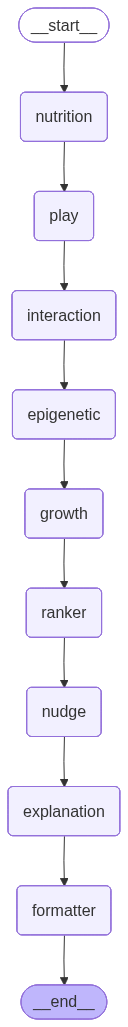

In [33]:
# ============================================================
# [Step 6] LangGraph Orchestrator 흐름 연결
# ------------------------------------------------------------
# 이 셀은 BabyCoach MVP의 실행 흐름을 LangGraph로 정의합니다.
#
# 흐름:
# Nutrition → Play → Interaction → Epigenetic → Growth
# → Ranker → Nudge → Explanation → Formatter → END
# ============================================================

graph_builder = StateGraph(BabyCoachState)

graph_builder.add_node("nutrition", nutrition_node)
graph_builder.add_node("play", play_node)
graph_builder.add_node("interaction", interaction_node)
graph_builder.add_node("epigenetic", epigenetic_node)
graph_builder.add_node("growth", growth_node)
graph_builder.add_node("ranker", ranker_node)
graph_builder.add_node("nudge", nudge_node)
graph_builder.add_node("explanation", explanation_node)
graph_builder.add_node("formatter", formatter_node)

graph_builder.set_entry_point("nutrition")

graph_builder.add_edge("nutrition", "play")
graph_builder.add_edge("play", "interaction")
graph_builder.add_edge("interaction", "epigenetic")
graph_builder.add_edge("epigenetic", "growth")
graph_builder.add_edge("growth", "ranker")
graph_builder.add_edge("ranker", "nudge")
graph_builder.add_edge("nudge", "explanation")
graph_builder.add_edge("explanation", "formatter")
graph_builder.add_edge("formatter", END)

babycoach_graph = graph_builder.compile()
babycoach_graph

In [35]:
# ============================================================
# [Step 6-2] 샘플 입력으로 end-to-end 실행 확인
# ------------------------------------------------------------
# 이 셀은 BabyCoach LangGraph 전체 흐름을 실행하고
# 최종 결과와 주요 중간 결과를 함께 확인합니다.
# ============================================================

result = babycoach_graph.invoke(sample_input)

print("===== FINAL OUTPUT =====")
pprint(result["final_output"])

print("\n===== DEBUG INFO =====")

print("\n[Nutrition Result]")
pprint(result["nutrition_result"])

print("\n[Play Result]")
pprint(result["play_result"])

print("\n[Interaction Result]")
pprint(result["interaction_result"])

print("\n[Epigenetic Result]")
pprint(result["epigenetic_result"])

print("\n[Growth Result]")
pprint(result["growth_result"])

print("\n[Ranked Actions]")
pprint(result["ranked_actions"])

print("\n[Nudge]")
print(result["nudge_message"])

print("\n[Explanation]")
print(result["explanation"])

===== FINAL OUTPUT =====
{'child_id': 'baby_001',
 'epigenetic_signals': {'cognitive_stimulation': 'rich',
                        'cognitive_stimulation_score': 0.88,
                        'risk_signals': [],
                        'social_bonding': 'high',
                        'stress_regulation': 'supportive'},
 'explanation': '한 줄 요약: 아기A(10개월)는 촉감·소리에 대한 탐색 성향이 뚜렷하고 반응적 상호작용과 정서적 안정 신호가 '
                '잘 보이며, 식단은 단백질이 다소 부족한 경향이 있습니다.  \n'
                '놀이·상호작용·영양 환경 해석: 손으로 만지고 흔드는 탐색 놀이를 좋아하고 접촉·반응성이 높아 인지 자극이 '
                '풍부한 반면 공동주의는 중간 수준이라 간단한 문제해결 놀이를 더해주면 좋고, 알레르기(달걀 흰자)를 고려해 '
                '단백질 재료는 소량으로 다양하게 도입하는 것이 바람직합니다.  \n'
                '발달 경험 측면의 의미: 이런 안정적이고 풍부한 감각 자극 환경은 아기의 탐색과 문제해결 경험에 긍정적인 '
                '영향을 줄 수 있어 주의집중과 인지 발달에 도움이 될 기회를 제공합니다.  \n'
                '오늘의 실천 제안: 오늘은 촉감·소리 장난감과 넣기·빼기 같은 간단한 문제해결 놀이를 짧게 함께하며 아기의 '
                '감각 탐색을 관찰해 보세요.',
 'growth_observation': {'improve_points': ['탐색 놀이를 유지하면서 간단한 문제해결 놀이를 조금 

In [37]:
# ============================================================
# [Step 6-2-1] 테스트 실행 함수
# ------------------------------------------------------------
# 다양한 입력을 빠르게 테스트하기 위한 helper 함수입니다.
# 추후 평가 루프(RAGAS처럼)로 확장 가능
# ============================================================

def run_babycoach_test(test_input: Dict[str, Any]):
    result = babycoach_graph.invoke(test_input)

    print("===== FINAL OUTPUT =====")
    pprint(result["final_output"])

    return result

In [39]:
# ============================================================
# [Step 6-2-2] 추가 샘플 테스트
# ------------------------------------------------------------
# 상호작용과 영양이 부족한 케이스 테스트
# 추천 변화 확인
# ============================================================

sample_input_2 = {
    "child_profile": {
        "child_id": "baby_002",
        "name": "아기B",
        "age_months": 12,
        "weight_kg": 9.2,
        "allergies": [],
        "notes": "요즘 새로운 놀이에 소극적인 편"
    },
    "meal_log": {
        "recent_foods": ["rice", "rice", "banana", "rice"],
        "protein_count_3d": 0,
        "vegetable_count_3d": 1,
        "food_diversity_3d": 2,
        "meal_refusal": False,
        "reaction_flags": []
    },
    "play_log": {
        "play_types": ["딸랑이 흔들기"],
        "focus_minutes": 3,
        "repeat_count": 2,
        "refusal": False,
        "child_led_ratio": 0.35,
        "parent_note": "새로운 놀이에는 금방 흥미를 잃음"
    },
    "interaction_log": {
        "touch_count": 1,
        "labeling_count": 0,
        "joint_attention_count": 1,
        "responsive_turns": 2,
        "flat_response": True,
        "parent_note": "반응을 잘 해주지 못한 날이 많았음"
    },
    "parent_query": "요즘 아이가 놀이에 집중을 잘 못하는데 어떻게 하면 좋을까요?"
}

result_2 = run_babycoach_test(sample_input_2)

===== FINAL OUTPUT =====
{'child_id': 'baby_002',
 'epigenetic_signals': {'cognitive_stimulation': 'moderate',
                        'cognitive_stimulation_score': 0.54,
                        'risk_signals': ['영양 경험 다양성 부족 가능성', '상호작용 안정성 보완 필요'],
                        'social_bonding': 'low',
                        'stress_regulation': 'watch'},
 'explanation': '아기B(12개월)는 새로운 놀이에 금방 흥미를 잃고 상호작용에 다소 소극적인 경향이 보입니다. '
                '놀이·상호작용·영양 환경을 보면 촉감·소리 중심 탐색에는 반응하지만 집중력과 문제해결 점수는 낮고, '
                '시선맞춤·스킨십·말걸기 빈도가 적으며 식재료 다양성이 낮은 경향이 있습니다. 환경이 발달 경험에 영향을 줄 수 '
                '있어 이런 특징은 탐색 지속력과 문제해결 능력, 사회적 결속을 키울 기회를 줄이므로 작은 상호작용 변화를 통해 '
                '천천히 개선해 가는 것이 도움이 됩니다. 관찰 포인트로는 촉감 자극을 어떻게 탐색하는지와 같은 식재료를 '
                '반복했을 때 반응 차이를 주의 깊게 살펴보세요. 오늘은 아기 시선에 맞춰 가볍게 손을 잡고 말 걸며, 촉감 '
                '있는 작은 장난감을 넣고 빼는 놀이를 짧게 함께 해보세요',
 'growth_observation': {'improve_points': ['식재료 경험의 다양성을 조금씩 넓혀볼 필요가 있습니다',
                                           '탐색 놀이를 유